<a href="https://colab.research.google.com/github/ngocnguyen10/loan-default-risk-model/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: FirstState Bank Loan Default Risk**


---

## **1. Executive Summary**

FirstState Community Bank is facing rising defaults, now above 10% versus a historical 6–7%, with each 1% increase costing about $1.4M annually. The goal is to estimate default risk for each applicant to support underwriting decisions. A logistic regression model is recommended for its transparency. The key metric is recall on defaults to ensure high-risk borrowers are identified.

Recommendation: use the model to flag high-risk applications for senior review, not to automatically deny loans. This keeps decisions consistent while maintaining relationship-based lending.







## **2. Business Problem**

The bank must reduce defaults without harming customer trust or rejecting good borrowers.

The decision is how to use a model to better detect risk. The more costly \$18,500. A false positive only loses about \$1,400 in interest but may hurt relationships. Because of this gap, the bank should focus on catching risky loans.

The model will not capture everything, such as customer relationships or context behind an application. Some inputs like ZIP code may also raise fairness concerns. This means the model should guide review, not replace it.

## **3. Data Exploration**

Describe your dataset:
- Number of observations
- Number of features
- Description of each feature
- Description of target variable

The dataset contains **2,000** observations, each representing a single loan application.

There are **6 original features** plus an identifier (`loan_id`) and the **target variable**:

-  **`loan_id`**: A unique identifier for each loan application.
-  **`annual_income`**: The applicant's reported annual income.
-  **`credit_score`**: The applicant's credit score.
-  **`debt_to_income_ratio`**: The applicant's debt-to-income ratio.
-  **`loan_amount`**: The amount of the loan requested.
-  **`employment_years`**: The number of years the applicant has been employed.
-  **`has_prior_default`**: A binary indicator (0 or 1) showing if the applicant has had a prior loan default.

-  The target variable is **`defaulted`**, a binary variable (0 = no default, 1 = default) indicating whether the loan ultimately defaulted.



**Data setup and loading**

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# Load data
DATA_URL = "https://raw.githubusercontent.com/prof-tcsmith/4641s26-data/main/final-project/Project-02-FirstState-Loan-Default/firststate_loans.csv"
df = pd.read_csv(DATA_URL)

### **3.1 Data Overview**

In [ ]:
# Display basic information about the dataset

print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())

Shape (rows, columns): (2000, 8)

Column names: ['loan_id', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'loan_amount', 'employment_years', 'has_prior_default', 'defaulted']


In [ ]:
print("Head (first 10 rows)")
display(df.head(10))

print("\nInformation")
df.info()

Head (first 10 rows)


,loan_id,annual_income,credit_score,debt_to_income_ratio,loan_amount,employment_years,has_prior_default,defaulted
0,20001,89883,741,0.36,16103,4.6,0,0
1,20002,97704,689,0.41,23693,1.4,0,0
2,20003,57045,691,0.05,31227,2.1,0,0
3,20004,69478,673,0.27,28766,9.0,0,1
4,20005,86902,781,0.44,19623,1.9,0,0
5,20006,103067,690,0.47,16218,0.4,0,0
6,20007,94697,818,0.46,20471,2.8,0,0
7,20008,25554,708,0.54,13712,2.6,0,1
8,20009,55373,691,0.42,4020,1.4,0,1
9,20010,72514,681,0.10,8866,0.0,0,0



Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_id               2000 non-null   int64  
 1   annual_income         2000 non-null   int64  
 2   credit_score          2000 non-null   int64  
 3   debt_to_income_ratio  2000 non-null   float64
 4   loan_amount           2000 non-null   int64  
 5   employment_years      2000 non-null   float64
 6   has_prior_default     2000 non-null   int64  
 7   defaulted             2000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 125.1 KB


In [ ]:
print("Summary Statistics")
display(df.describe().T)

print("\nMissing values per column")
print(df.isna().sum())

Summary Statistics


,count,mean,std,min,25%,50%,75%,max
loan_id,2000.0,21000.50000,577.494589,20001.00,20500.75,21000.50,21500.25,22000.0
annual_income,2000.0,62408.16400,20611.136921,20000.00,47830.25,61922.00,76595.50,129205.0
credit_score,2000.0,693.33700,63.777388,520.00,650.00,694.00,737.00,840.0
debt_to_income_ratio,2000.0,0.35944,0.178520,0.05,0.22,0.35,0.49,0.8
loan_amount,2000.0,21857.50200,8454.147953,3000.00,16042.00,21806.50,27469.25,53301.0
employment_years,2000.0,4.63820,4.564060,0.00,1.30,3.30,6.50,30.0
has_prior_default,2000.0,0.08650,0.281171,0.00,0.00,0.00,0.00,1.0
defaulted,2000.0,0.09200,0.289098,0.00,0.00,0.00,0.00,1.0



Missing values per column
loan_id                 0
annual_income           0
credit_score            0
debt_to_income_ratio    0
loan_amount             0
employment_years        0
has_prior_default       0
defaulted               0
dtype: int64


### **3.2 Target-Class Balance Analysis**

In [ ]:
# Check the balance of the target variable
print("Target variable ('defaulted') distribution:")
display(df['defaulted'].value_counts())

print("\nTarget variable ('defaulted') percentage distribution:")
display(df['defaulted'].value_counts(normalize=True) * 100)

Target variable ('defaulted') distribution:


,count
defaulted,
0,1816
1,184



Target variable ('defaulted') percentage distribution:


,proportion
defaulted,
0,90.8
1,9.2


From the results, about 9.2% of loans default (1) and 90.8% do not (0). This shows a clear class imbalance.
This matters because defaults are rare but costly. Missing a default has a much higher financial impact than incorrectly flagging a good borrower. The model should account for this by focusing on identifying high-risk loans.

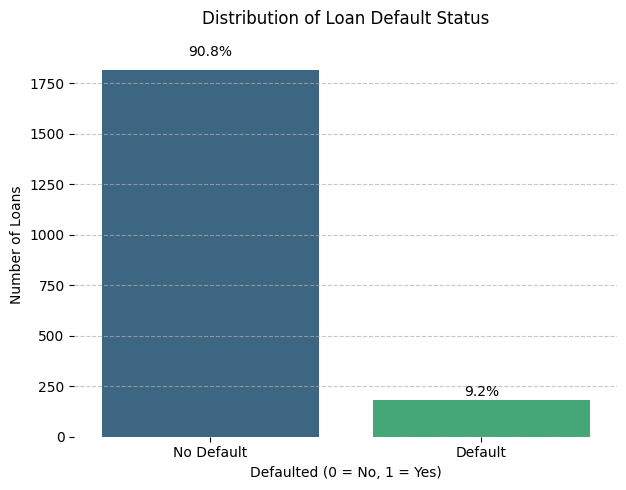

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable
plt.figure(figsize=(7, 5))
sns.countplot(x='defaulted', data=df, palette='viridis', hue='defaulted', legend=False)
plt.title('Distribution of Loan Default Status', pad=20) # Increased pad for title
plt.xlabel('Defaulted (0 = No, 1 = Yes)')
plt.ylabel('Number of Loans')
plt.xticks([0, 1], ['No Default', 'Default'])

# Add percentage labels on top of the bars
total = len(df['defaulted'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() * 1.03 # Adjust offset to be proportional to bar height
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.box(False) # Remove the outer box/frame
plt.show()

### **3.3 Feature-Target Relationship Visualizations**

This will help us understand which features might be strong predictors of loan default.

**Relationship between Credit Score and Default Status**

Next, let's visualize the relationship between credit_score and the defaulted status using another box plot. Credit score is typically a strong indicator of creditworthiness, so we expect to see a noticeable difference.

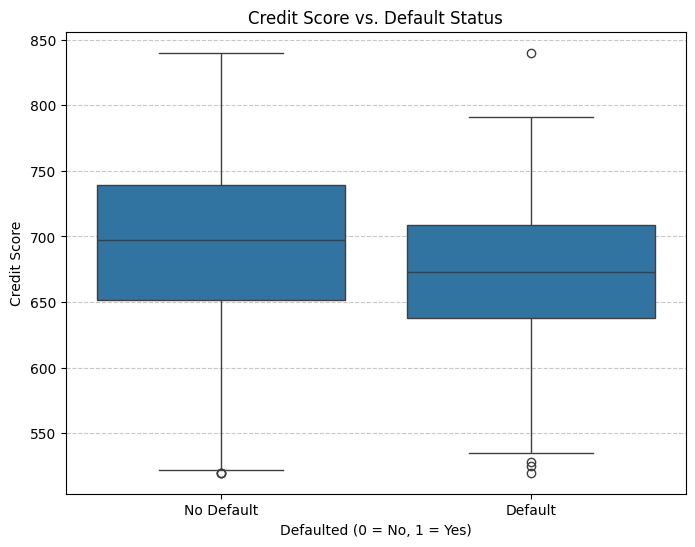

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='defaulted', y='credit_score', data=df, hue='defaulted', palette='viridis')
plt.title('Credit Score vs. Default Status')
plt.xlabel('Defaulted (0 = No, 1 = Yes)')
plt.ylabel('Credit Score')
plt.xticks([0, 1], ['No Default', 'Default']) # Keep x-tick labels for clarity
plt.legend(title='Default Status', labels=['No Default', 'Default'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Prior default vs. Current default**

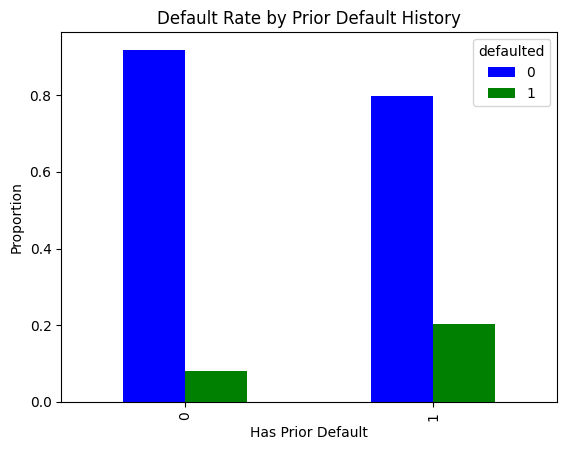

In [ ]:
import pandas as pd

pd.crosstab(df['has_prior_default'], df['defaulted'], normalize='index').plot(kind='bar', color=['blue', 'green'])
plt.title("Default Rate by Prior Default History")
plt.xlabel("Has Prior Default")
plt.ylabel("Proportion")
plt.xticks(rotation=90) # Make x-axis labels vertical
plt.show()

### **4. Model Building**


To estimate the probability that a borrower will default, we use a logistic regression model. This approach is appropriate because the target variable is binary (default vs. repaid), and the model produces probabilities that can be interpreted as risk scores.

The logistic regression technique is easy to interpret, meaning that FirstState will be able to understand how different attributes of the borrowers influence their probability of defaulting on loan repayment.

###4.1 Train/Test Split

We split the dataset into 70% training and 30% testing data. Because only about 10%
of loans default, we use stratified sampling to preserve this imbalance in both sets.

This ensures the model is trained and evaluated on representative data.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

DATA_URL = "https://raw.githubusercontent.com/prof-tcsmith/4641s26-data/main/final-project/Project-02-FirstState-Loan-Default/firststate_loans.csv"
df = pd.read_csv(DATA_URL)

In [ ]:
FEATURES = [
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "loan_amount",
    "employment_years",
    "has_prior_default",
]
TARGET = "defaulted"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT (70/30, stratified on 'defaulted')")
print("=" * 60)
print(f"  Train : {len(X_train):,} loans | defaults: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"  Test  : {len(X_test):,}  loans | defaults: {y_test.sum():,} ({y_test.mean():.1%})")
print()
print("  stratify=y ensures the 9% default rate is preserved")
print("  in both sets — critical given the class imbalance.")

TRAIN / TEST SPLIT (70/30, stratified on 'defaulted')
  Train : 1,400 loans | defaults: 129 (9.2%)
  Test  : 600  loans | defaults: 55 (9.2%)

  stratify=y ensures the 9% default rate is preserved
  in both sets — critical given the class imbalance.


###4.2 Model Training

We train a logistic regression model using the training dataset (70% of the data).
The model learns the relationship between borrower characteristics and the likelihood
of default based on historical loan outcomes.

This split balances two priorities: having enough data to train a stable model while keeping a sufficiently large test set to reliably evaluate performance, especially for the minority “default” class.

Logistic regression is suitable for this problem because it produces probability
estimates that can be interpreted as risk scores. These scores can help FirstState’s
underwriters assess how risky a loan application is, rather than making a simple
approve/deny decision.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained on 70% training set.")

Logistic Regression model trained on 70% training set.


###4.3 Interpretation of Odds Ratios

Odds ratio > 1 indicates that the feature increases the likelihood of default,
while odds ratio < 1 indicates a protective effect.

The model identifies several key drivers of default risk:

- Debt-to-income ratio: The strongest risk driver. Borrowers with high DTI
  have significantly higher default risk because more income is already
  committed to debt.

- Prior default history: A strong predictor of future default. Past behavior
  is highly indicative of future behavior.

- Loan amount: Larger loans increase repayment burden and slightly increase risk.

- Employment years: Longer employment indicates income stability and reduces risk.

- Credit score: Higher credit scores significantly reduce default risk.

- Annual income: Higher income provides financial flexibility and strongly reduces risk.

These results align with standard lending intuition, suggesting the model is capturing
meaningful patterns in borrower behavior.

ODDS RATIOS — KEY RISK DRIVERS
             Feature  Log-Odds  Odds Ratio     Direction
debt_to_income_ratio  2.187415    8.912144 ↑ Higher Risk
   has_prior_default  1.203538    3.331886 ↑ Higher Risk
         loan_amount  0.000034    1.000034 ↑ Higher Risk
       annual_income -0.000042    0.999958  ↓ Lower Risk
        credit_score -0.008072    0.991961  ↓ Lower Risk
    employment_years -0.045824    0.955210  ↓ Lower Risk


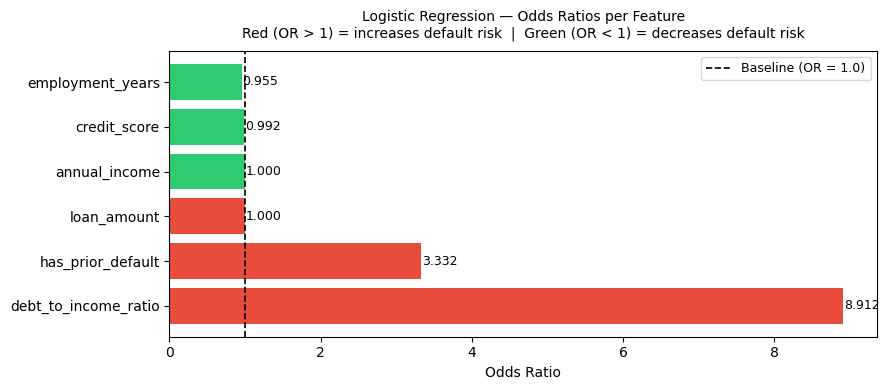

In [ ]:
import matplotlib.pyplot as plt

odds_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Log-Odds":   model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0]),
    "Direction":  ["↑ Higher Risk" if v > 1 else "↓ Lower Risk"
                   for v in np.exp(model.coef_[0])]
}).sort_values("Odds Ratio", ascending=False).reset_index(drop=True)

print("=" * 60)
print("ODDS RATIOS — KEY RISK DRIVERS")
print("=" * 60)
print(odds_df.to_string(index=False))

# Bar chart
colors = ["#e74c3c" if v > 1 else "#2ecc71" for v in odds_df["Odds Ratio"]]
plt.figure(figsize=(9, 4))
bars = plt.barh(odds_df["Feature"], odds_df["Odds Ratio"], color=colors)
plt.axvline(x=1.0, color="black", linestyle="--", linewidth=1.2, label="Baseline (OR = 1.0)")
plt.xlabel("Odds Ratio")
plt.title(
    "Logistic Regression — Odds Ratios per Feature\n"
    "Red (OR > 1) = increases default risk  |  Green (OR < 1) = decreases default risk",
    fontsize=10, pad=10
)
for bar, val in zip(bars, odds_df["Odds Ratio"]):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center", fontsize=9
    )
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

These results indicate that the model is capturing meaningful and intuitive
relationships between borrower characteristics and default risk, making it a
useful tool for supporting lending decisions.

The next step is to evaluate how well the model performs on unseen data
and assess whether it is effective at identifying high-risk borrowers.


### **5. Model Evaluation**


We evaluate the model on the 30% test set. Because default is relatively rare,
accuracy alone is not sufficient. Instead, we focus on metrics that reflect
the business cost of different types of errors.

### 5.1 Generating Predictions

After training the model, we apply it to the test dataset to generate predictions.

The model produces two types of outputs:

- **Predicted class (0 or 1):**  
  Indicates whether the model classifies a borrower as likely to repay (0) or default (1).

- **Predicted probability (risk score):**  
  Represents the estimated probability that a borrower will default. This is more useful
  for business decision-making because it allows the bank to rank applicants by risk level.

These predictions will be used to evaluate model performance and assess how well the model
identifies high-risk borrowers.


This is especially important because FirstState intends to use the model as a
decision-support tool rather than an automated approval or denial system.

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

print("✓ Predictions generated on 30% test set.")
print(f"  Total loans evaluated : {len(y_test)}")
print(f"  Predicted as Default  : {y_pred.sum()}")
print(f"  Predicted as Repaid   : {(y_pred == 0).sum()}")

✓ Predictions generated on 30% test set.
  Total loans evaluated : 600
  Predicted as Default  : 2
  Predicted as Repaid   : 598


###5.2 Business Interpretation of Model Performance

- Accuracy alone is not sufficient.
  Since only about 10% of loans default, a model that predicts "repaid" for
  every loan would still achieve high accuracy while failing to identify risk.

- Precision (Default) tells how many flagged borrowers actually default.
  Low precision means more good borrowers are flagged for review.

- Recall (Default) measures how many actual defaults are correctly identified.
  This is the most important metric because missing a default can cost
  approximately $18,500 per loan.

- F1 Score balances precision and recall.

From a business perspective, recall is the most critical metric. The bank would
prefer to flag more applications for review rather than miss a borrower who is
likely to default, given the large financial loss associated with missed defaults.

This reinforces the idea that the model should be used to flag high-risk applications
for further review, rather than to automatically approve or deny loans.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nKEY METRICS")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")


KEY METRICS
Accuracy : 0.908
Precision: 0.500
Recall   : 0.018
F1 Score : 0.035


### 5.3 Confusion Matrix and ROC Curve

To better understand how the model performs, we examine both the confusion matrix and the ROC curve.

- The **confusion matrix** shows how the model’s predictions compare to actual outcomes, allowing us to see the number of correct and incorrect classifications.
- The **ROC curve** evaluates the model’s ability to distinguish between borrowers who will default and those who will not across different thresholds.

Together, these tools provide a more complete picture of model performance beyond simple accuracy.

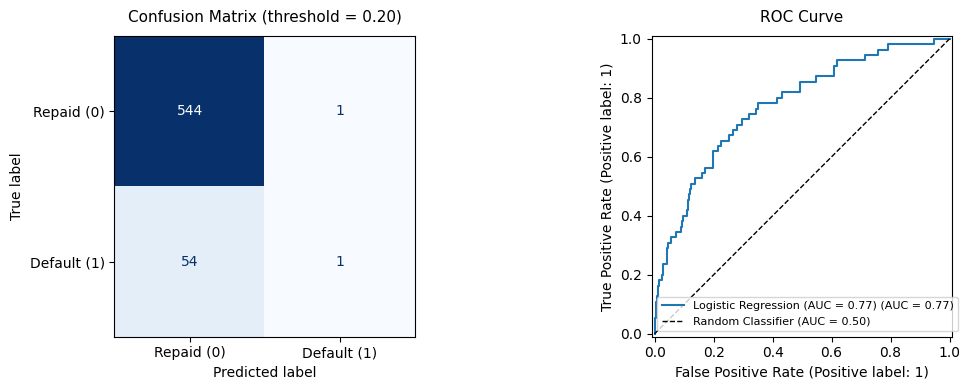

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Repaid (0)", "Default (1)"],
    cmap="Blues", colorbar=False, ax=axes[0]
)
axes[0].set_title("Confusion Matrix (threshold = 0.20)", fontsize=11, pad=10)

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.2f})",
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier (AUC = 0.50)")
axes[1].set_title("ROC Curve", fontsize=11, pad=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

###5.4 Model Performance Metrics

We summarize model performance using several key metrics:

- **Accuracy** measures overall correctness.
- **Precision (Default)** indicates how many borrowers flagged as high-risk actually default.
- **Recall (Default)** measures how many actual defaults are correctly identified.
- **F1 Score** balances precision and recall.
- **ROC-AUC** reflects the model’s ability to distinguish between default and non-default cases.

These metrics help evaluate how well the model identifies high-risk borrowers and the trade-offs between different types of errors.


In [ ]:
from sklearn.metrics import classification_report

print("─" * 60)
print("Classification Report")
print("─" * 60)
print(classification_report(y_test, y_pred, target_names=["Repaid", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

────────────────────────────────────────────────────────────
Classification Report
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Repaid       0.91      1.00      0.95       545
     Default       0.50      0.02      0.04        55

    accuracy                           0.91       600
   macro avg       0.70      0.51      0.49       600
weighted avg       0.87      0.91      0.87       600

ROC-AUC: 0.774


###5.5 Business Cost of Prediction Errors

To translate model performance into business impact, we map prediction errors to their financial consequences.

- A **false negative (missed default)** occurs when the model fails to identify a borrower who will default.  
  → This results in an average loss of approximately **$18,500 per loan**.

- A **false positive (false flag)** occurs when the model incorrectly flags a creditworthy borrower as high-risk.  
  → This leads to an opportunity cost of about **$1,400 in lost interest revenue** and additional review effort.

By quantifying these errors, we can better understand the real financial impact of model performance and determine which type of error is more costly to the bank.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("─" * 60)
print("Confusion Matrix Dollar Breakdown")
print("─" * 60)
print(f"  True Negatives  (correctly predicted Repaid)  : {tn:>4}")
print(f"  False Positives (good borrowers flagged)       : {fp:>4}  ← $1,400 cost each")
print(f"  False Negatives (missed defaults)              : {fn:>4}  ← $18,500 cost each")
print(f"  True Positives  (correctly caught defaults)    : {tp:>4}")
print()

fn_cost = fn * 18_500
fp_cost = fp * 1_400
total   = fn_cost + fp_cost

print(f"  Estimated cost of missed defaults  : ${fn_cost:>10,.0f}")
print(f"  Estimated cost of false flags      : ${fp_cost:>10,.0f}")
print(f"  Total estimated error cost         : ${total:>10,.0f}")
print()
print(f"  → Each missed default costs 13x more than a false flag.")
print(f"    This is why Recall on the Default class is the metric")
print(f"    Robert should track above all others.")

────────────────────────────────────────────────────────────
Confusion Matrix Dollar Breakdown
────────────────────────────────────────────────────────────
  True Negatives  (correctly predicted Repaid)  :  544
  False Positives (good borrowers flagged)       :    1  ← $1,400 cost each
  False Negatives (missed defaults)              :   54  ← $18,500 cost each
  True Positives  (correctly caught defaults)    :    1

  Estimated cost of missed defaults  : $   999,000
  Estimated cost of false flags      : $     1,400
  Total estimated error cost         : $ 1,000,400

  → Each missed default costs 13x more than a false flag.
    This is why Recall on the Default class is the metric
    Robert should track above all others.


### 5.6 Business Interpretation

From a business perspective, not all prediction errors are equally costly.

The results clearly show that **false negatives are significantly more expensive than false positives**, with each missed default costing roughly **13 times more** than incorrectly flagging a good borrower.

The model’s performance highlights a critical issue. With a recall of only **1.8%**, the model is missing the vast majority of high-risk borrowers. In fact, the confusion matrix shows that **54 out of 55 defaults were not detected**, exposing the bank to substantial financial risk.

This problem is largely driven by the default classification threshold of **0.50**, which is too conservative for this business context. As a result, many borrowers with moderate risk probabilities are incorrectly classified as “repaid.”

To better align with FirstState’s objectives, the bank should consider **lowering the decision threshold** or relying more heavily on **predicted probabilities (risk scores)** to identify high-risk applicants.

Overall, the model should be used as a **risk-screening tool** to flag applications for further human review, rather than as an automated approval or denial system.

In [ ]:
actual_defaults = y_test.sum()
caught_defaults = ((y_test == 1) & (y_pred == 1)).sum()
missed_defaults = ((y_test == 1) & (y_pred == 0)).sum()

print("=" * 60)
print("DEFAULT DETECTION PERFORMANCE")
print("=" * 60)
print(f"Actual defaults in test set   : {actual_defaults}")
print(f"Defaults correctly detected  : {caught_defaults}")
print(f"Defaults missed (False Neg.) : {missed_defaults}")
print(f"Recall (Default)             : {recall:.3f}")

DEFAULT DETECTION PERFORMANCE
Actual defaults in test set   : 55
Defaults correctly detected  : 1
Defaults missed (False Neg.) : 54
Recall (Default)             : 0.018


### 5.7 Threshold Adjustment

The previous results show that the model performs poorly at identifying defaults
when using the default classification threshold of 0.50.

To improve recall, we test lower decision thresholds using predicted probabilities.
Lowering the threshold allows the model to classify more borrowers as high-risk,
which can help capture more potential defaults.

This adjustment is important because missing a default is significantly more costly
than incorrectly flagging a low-risk borrower.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 65)
print("THRESHOLD COMPARISON — Precision / Recall / F1")
print("=" * 65)

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]
results = []

for t in thresholds:
    y_pred_t  = (y_prob >= t).astype(int)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall    = recall_score(y_test, y_pred_t, zero_division=0)
    f1        = f1_score(y_test, y_pred_t, zero_division=0)
    caught    = y_pred_t[y_test == 1].sum()
    missed    = (y_test == 1).sum() - caught
    results.append({
        "Threshold": t,
        "Precision": round(precision, 3),
        "Recall":    round(recall, 3),
        "F1":        round(f1, 3),
        "Defaults Caught": caught,
        "Defaults Missed": missed
    })
    print(f"  Threshold = {t:.2f} | Precision = {precision:.3f} | "
          f"Recall = {recall:.3f} | F1 = {f1:.3f} | "
          f"Caught = {caught} / {(y_test==1).sum()}")

results_df = pd.DataFrame(results)

THRESHOLD COMPARISON — Precision / Recall / F1
  Threshold = 0.50 | Precision = 0.500 | Recall = 0.018 | F1 = 0.035 | Caught = 1 / 55
  Threshold = 0.40 | Precision = 0.714 | Recall = 0.091 | F1 = 0.161 | Caught = 5 / 55
  Threshold = 0.30 | Precision = 0.458 | Recall = 0.200 | F1 = 0.278 | Caught = 11 / 55
  Threshold = 0.20 | Precision = 0.297 | Recall = 0.400 | F1 = 0.341 | Caught = 22 / 55
  Threshold = 0.10 | Precision = 0.204 | Recall = 0.673 | F1 = 0.314 | Caught = 37 / 55


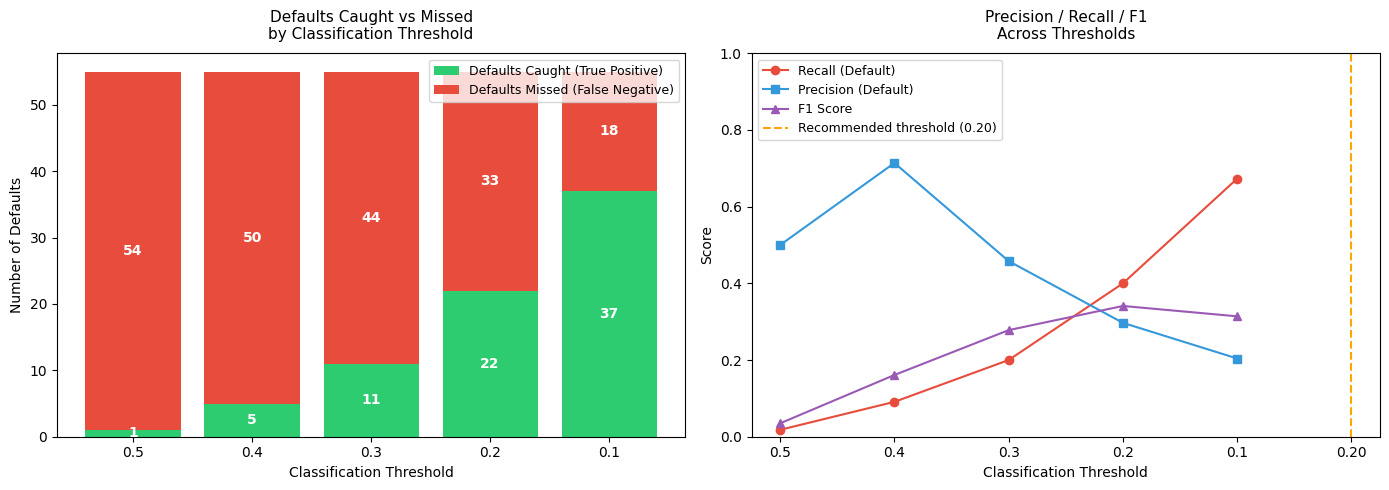

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = [str(r["Threshold"]) for r in results]
caught = [r["Defaults Caught"] for r in results]
missed = [r["Defaults Missed"] for r in results]

axes[0].bar(x, caught, color="#2ecc71", label="Defaults Caught (True Positive)")
axes[0].bar(x, missed, bottom=caught, color="#e74c3c", label="Defaults Missed (False Negative)")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Number of Defaults")
axes[0].set_title("Defaults Caught vs Missed\nby Classification Threshold", fontsize=11, pad=10)
axes[0].legend(fontsize=9)
for i, (c, m) in enumerate(zip(caught, missed)):
    axes[0].text(i, c / 2, str(c), ha="center", va="center",
                 color="white", fontweight="bold", fontsize=10)
    axes[0].text(i, c + m / 2, str(m), ha="center", va="center",
                 color="white", fontweight="bold", fontsize=10)

#Precision vs Recall line chart
precisions = [r["Precision"] for r in results]
recalls    = [r["Recall"] for r in results]
f1s        = [r["F1"] for r in results]

axes[1].plot(x, recalls,    marker="o", color="#e74c3c", label="Recall (Default)")
axes[1].plot(x, precisions, marker="s", color="#3498db", label="Precision (Default)")
axes[1].plot(x, f1s,        marker="^", color="#9b59b6", label="F1 Score")
axes[1].axvline(x="0.20", color="orange", linestyle="--", linewidth=1.5,
                label="Recommended threshold (0.20)")
axes[1].set_xlabel("Classification Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1\nAcross Thresholds", fontsize=11, pad=10)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


The comparison of different classification thresholds shows a clear trade-off between precision and recall.

At the default threshold of 0.50, the model achieves high precision but extremely low recall (only 1.8%), meaning it fails to identify most high-risk borrowers.

As the threshold is lowered, recall increases significantly, allowing the model to capture more potential defaults. However, this comes at the cost of lower precision, meaning more low-risk borrowers are flagged for review.

A threshold of **0.20 provides the best balance**, achieving a recall of 40.0% while maintaining a reasonable precision of 29.7%. It also produces the highest F1 score among all tested thresholds.


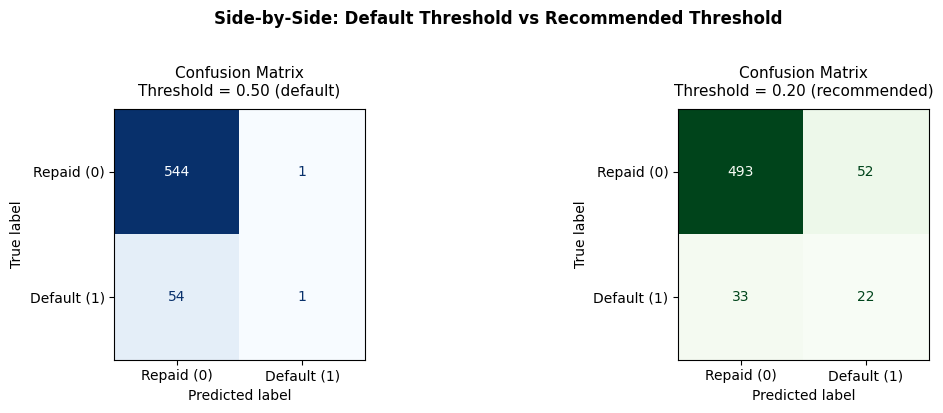


FINANCIAL IMPACT: Threshold 0.50 vs Threshold 0.20

  Threshold Default (0.50):
    Defaults caught (TP) :    1  |  Missed (FN) :   54
    Good borrowers flagged (FP) :    1
    Cost of missed defaults : $   999,000
    Cost of false flags     : $     1,400
    Total estimated cost    : $ 1,000,400

  Threshold Recommended (0.20):
    Defaults caught (TP) :   22  |  Missed (FN) :   33
    Good borrowers flagged (FP) :   52
    Cost of missed defaults : $   610,500
    Cost of false flags     : $    72,800
    Total estimated cost    : $   683,300


In [ ]:
#Confusion Matrix: 0.50 vs 0.20
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, (y_prob >= 0.50).astype(int),
    display_labels=["Repaid (0)", "Default (1)"],
    cmap="Blues", colorbar=False, ax=axes2[0]
)
axes2[0].set_title("Confusion Matrix\nThreshold = 0.50 (default)", fontsize=11, pad=10)

ConfusionMatrixDisplay.from_predictions(
    y_test, (y_prob >= 0.20).astype(int),
    display_labels=["Repaid (0)", "Default (1)"],
    cmap="Greens", colorbar=False, ax=axes2[1]
)
axes2[1].set_title("Confusion Matrix\nThreshold = 0.20 (recommended)", fontsize=11, pad=10)

plt.suptitle("Side-by-Side: Default Threshold vs Recommended Threshold",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#Dollar Cost Comparison: 0.50 vs 0.20
print("\n" + "=" * 65)
print("FINANCIAL IMPACT: Threshold 0.50 vs Threshold 0.20")
print("=" * 65)

for t, label in [(0.50, "Default (0.50)"), (0.20, "Recommended (0.20)")]:
    y_pred_t = (y_prob >= t).astype(int)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    fn_cost = fn * 18_500
    fp_cost = fp * 1_400
    total   = fn_cost + fp_cost
    print(f"\n  Threshold {label}:")
    print(f"    Defaults caught (TP) : {tp:>4}  |  Missed (FN) : {fn:>4}")
    print(f"    Good borrowers flagged (FP) : {fp:>4}")
    print(f"    Cost of missed defaults : ${fn_cost:>10,.0f}")
    print(f"    Cost of false flags     : ${fp_cost:>10,.0f}")
    print(f"    Total estimated cost    : ${total:>10,.0f}")

From a business perspective, this trade-off is acceptable because the cost of missing a default
(**18,500 dollars per loan**) is significantly higher than the cost of reviewing additional applications
(**1,400 dollars per loan**).

Comparing the two thresholds highlights the financial impact of this decision. At the default
threshold of 0.50, the model results in an estimated total error cost of approximately
**$1,000,400**, driven primarily by a large number of missed defaults.

In contrast, lowering the threshold to 0.20 reduces the total estimated error cost to
approximately **$683,300**, despite increasing the number of false positives.

This represents a substantial reduction in expected financial loss, making the lower threshold
a more effective choice for the bank.

Therefore, lowering the threshold improves the model’s usefulness as a risk detection tool.


These results suggest that the default threshold of 0.50 is too conservative for FirstState’s needs.

Instead, the bank should use a lower threshold (such as 0.20) or rely directly on predicted probabilities to identify high-risk borrowers.

This approach aligns with FirstState’s objective of using the model to **flag applications for further review**, rather than automatically approve or deny loans.

## **6. Model Selection & Business Decision**

To determine the most appropriate model for FirstState, we compare model performance and different classification thresholds in the context of business costs.

We selected a Logistic Regression model. While other algorithms might exist, Logistic Regression was chosen because it provides highly interpretable odds ratios (allowing us to explain exactly why a borrower is risky) and outputs continuous probabilities rather than just binary predictions.


### 6.1 Metric Selection & The Class Imbalance Problem
For FirstState Bank, the most critical metric is Recall (Sensitivity) for the Default class to identify actual high-risk borrowers.

**Class Imbalance Consideration:**
Our data exploration revealed a significant class imbalance (only 9.2% defaults). In highly imbalanced datasets, overall *Accuracy* is a dangerous metric. A model that simply predicted "repaid" for everyone achieves nearly 91% accuracy while completely missing defaults, exposing the bank to massive risk.


### 6.2 Financial Trade-Off Analysis

*   **The Cost of a False Negative (Missed Default, occurs when a borrower who will default is classified as
"repaid.")
:** ~\$18,500 per loan. This is our worst-case scenario.
*   **The Cost of a False Positive (False Alarm, occurs when a creditworthy borrower is flagged as high-risk):** ~\$1,400 per loan in lost interest and administrative review time.

Because a missed default is **over 13 times more expensive** than a false alarm, the model must prioritize catching as many actual defaults as possible. We gladly accept reviewing a few more false positives as the cost of doing business to stop catastrophic financial losses.

### 6.3 Model Threshold Adjustment

Standard models use a 0.50 probability threshold, assuming all errors have equal costs. For FirstState, this fails entirely:

* At the default threshold of 0.50: the model achieves high accuracy but extremely low recall (1.8%), meaning it fails to identify most high-risk borrowers (missed 54 of 55 actual defaults). This makes it unsuitable for the bank’s objective of reducing default losses and results in over $1,000,000 error cost.
* At recommended 0.2 threshold: recall improves substantially, allowing the model to detect a much larger proportion of potential defaults (40%). Although this increases the number of false positives, the overall financial impact is lower because fewer costly defaults are missed.

In practice, the model should not be used for automatic approval or rejection. Instead,
it should function as a **risk-screening tool**, where applications flagged as high-risk
are reviewed by a human underwriter before making the final decision.

This approach balances financial risk reduction with FirstState’s commitment to fair and
community-oriented lending.

## **7. Strategic Recommendations**

### 7.1 Model Implementation Strategy
##### **Balanced Risk vs. Return**
While catching defaults is critical, optimizing *only* for Recall would mean flagging nearly every application, overwhelming underwriters and costing \$1,400 in review time and lost interest per false alarm. FirstState must prioritize a threshold that balances risk and return—maximizing default detection (Recall) up to the point where the cost of reviewing false positives outweighs the \$18,500 saved from preventing a default.

##### **Continuous Probability Scoring (Not Binary Cutoffs)**

We recommend that FirstState Bank transition away from binary predictions (`predict`) and instead utilize continuous probability scores (`predict_proba`). Binary predictions use a rigid 0.50 cutoff that ignores the nuance of risk. Probability scores allow the bank to see the degree of default risk for each applicant, transforming a "Yes/No" decision into a "Risk Score" that can be managed.

### 7.2 Proposed Operational Workflow
##### **1. Workflow Proposal: Risk Tiers**
To protect the bank's relationship-based lending model, FirstState should implement a tiered risk workflow rather than an automated decision engine:
*   **Low Risk (e.g., < 15% default probability):** Fast-track for the standard approval pipeline to ensure good borrowers are not delayed.
*   **Moderate Risk (e.g., 15% - 30% default probability):** Flag for standard underwriter review. The 15% - 30% moderate risk tier surrounds our optimal 0.20 threshold, ensuring borderline cases receive the manual review they require.
*   **High Risk (e.g., > 30% default probability):** Escalate to senior underwriters for deep evaluation.
*   **No Automatic Denials:** Critically, there should be no automatic denial of loans, even for the bottom percentage of applicants, preserving the bank's customer relationships.

This strategy ensures that the model acts as an Underwriting Co-pilot, providing a data-driven safety net without replacing the "human-in-the-loop" relationship lending that defines FirstState Bank.
highest-impact interventions.
##### **2. Underwriter Explainability**
Because we utilized an interpretable Logistic Regression model, the risk score provided to underwriters should include the top contributing factors. This transforms the model from a "black box" into an actionable Underwriting Co-pilot.


## **8. Limitations & Next Steps**

### 8.1 Model Limitations
1.  **Lack of Economic Context:** The model is trained on a static snapshot of 2,000 loan applications and lacks macroeconomic indicators like interest rates, local employment trends, or inflation—all of which heavily influence a borrower's likelihood to default on a loan.

2.  **Missing Underwriting Variables:** The dataset lacks key lending features, including whether a loan is secured (collateralized) or unsecured dramatically shifts default risk. It also misses loan purpose (e.g., debt consolidation vs. vacation) and the presence of a co-signer.

3.  **Static Financial Picture:** The variables represent a single point in time. They do not capture the trajectory of a borrower's financial health, such as rapidly accumulating credit card debt or steadily depleting savings, which are strong early warning signs of impending default.

4.  **Lack of Qualitative Context:** The model evaluates historical numerical data but cannot understand the context behind the numbers, such as a temporary medical crisis versus chronic financial mismanagement.
    *   **Deployment Safeguard:** To mitigate these, we recommend a "Human-in-the-Loop" approach. The model serves as an "Early-Warning Radar" for underwriters, never replacing human judgment or automatically denying credit.

### 8.2 Next Steps & Model Evolution
1.  **Enhance the Dataset:** FirstState should incorporate additional features, such as applicant cash flow trends (e.g., consistent positive balances), localized economic data (regional unemployment), and detailed loan characteristics to isolate the exact triggers of loan defaults.

2.  **Test Advanced Algorithms:** Evaluate non-linear models like Random Forest or XGBoost. These may improve Recall by capturing complex interactions (e.g., how high income offsets high DTI) without flagging too many false positives.

3.  **Establish Model Monitoring:** Set up a pipeline to track model performance against actual repayment outcomes. As the economy shifts, borrower default behavior will change (e.g., a 700 credit score may carry different risk during a recession). The bank must continuously validate the model and retrain it to ensure it catches defaults accurately over time.
4.  **Develop Shadow Mode Evaluation Metrics:** Since actual defaults take time to materialize, establish proxy metrics to evaluate the model during its "Shadow Mode" phase.
    * **Human-Model Agreement:** Track the concordance between the model's risk score and the senior underwriter's actual decision to calibrate the risk appetite.
    * **Early Warning Proxies:** Monitor leading indicators such as First Payment Defaults (FPD) or 30-day delinquencies to validate the model's predictive power without waiting for full loan charge-offs.

## **9. Conclusion**
The business problem was to help FirstState Community Bank better estimate loan default risk to mitigate the financial impact of rising defaults without harming customer relationships or unfairly rejecting creditworthy borrowers.

Our team addressed this by analyzing historical loan application data, prioritizing Recall to account for the high cost of missed defaults, and training an interpretable logistic regression model. Recognizing that a missed default (18,500) cost significantly more than (1,400), we adjusted the risk decision threshold to 0.20 to capture a much higher percentage of risky loans.

The analysis showed that a borrower's debt-to-income ratio, prior default history, and credit score play the most critical roles in determining repayment probability. Lowering the decision threshold dramatically improved the model's ability to detect these risky applications, reducing estimated financial exposure by over $300,000 within our test portfolio.

The model serves as a highly effective "Underwriting Co-pilot," demonstrating that a data-driven, tiered risk routing approach can deliver stable and interpretable risk scores. These insights directly support the bank's lending strategy by proactively flagging high-risk applications for senior underwriter review rather than automating automated denials, thereby preserving the bank's community-focused lending model.

The next step is to deploy the model in a 60-90 day "Shadow Mode" to monitor real-world performance against early warning proxies (such as 30-day delinquencies) and to eventually expand the dataset with macroeconomic indicators to further refine risk prediction quality.